Analysis
1.
 What is the average age of users?
2.
 Average age by gender?
3.
 Number of users per gender?
4.
 Top 10 cities with the most users?
5.
 Average height and weight overall?
6.
 Is there any obvious relationship between age and height/weight?
Prove your answer through Seaborn Visualizations (create at least 5 plots)

In [11]:
# ********************** IMPORTS ********************** #

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv('cleaned_users.csv')
df.head()

,id,firstName,lastName,maidenName,age,gender,email,phone,username,password,...,city,company_name,company_location,cardExpire,cardNumber,cardType,currency,iban,hair_color,hair_type
0,1,Emily,Johnson,Smith,29,female,emily.johnson@x.dummyjson.com,+81 965-431-3024,emilys,emilyspass,...,Phoenix,"Dooley, Kozey and Cronin",San Francisco,05/28,3693233511855044,Diners Club International,GBP,GB74MH2UZLR9TRPHYNU8F8,Brown,Curly
1,2,Michael,Williams,NaN,36,male,michael.williams@x.dummyjson.com,+49 258-627-6644,michaelw,michaelwpass,...,Houston,Spinka - Dickinson,Los Angeles,01/30,3530633803003665,JCB,USD,DE26362283149158045865,Green,Straight
2,3,Sophia,Brown,NaN,43,female,sophia.brown@x.dummyjson.com,+81 210-652-2785,sophiab,sophiabpass,...,Washington,Schiller - Zieme,Dallas,10/27,6011212053392887,Discover,EUR,DE12191213468288004835,White,Wavy
3,4,James,Davis,NaN,46,male,james.davis@x.dummyjson.com,+49 614-958-9364,jamesd,jamesdpass,...,Seattle,Pagac and Sons,Fort Worth,07/30,5303440212268149,Mastercard,CAD,DE01300746880579852937,Blonde,Straight
4,5,Emma,Miller,Johnson,31,female,emma.miller@x.dummyjson.com,+91 759-776-1614,emmaj,emmajpass,...,Jacksonville,Graham - Gulgowski,San Antonio,07/30,5237188057591130,Mastercard,NZD,DE19182355652037133559,White,Straight


Overall Average Age: 33.14 years
************************************


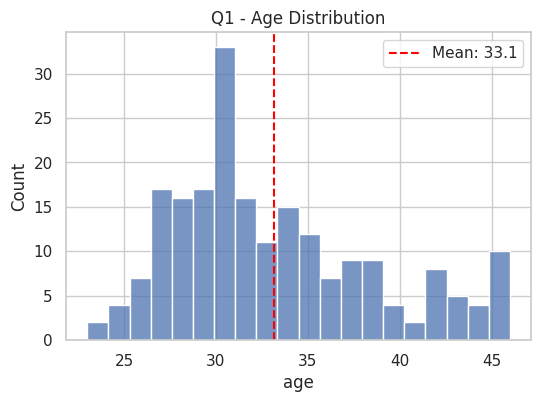

In [20]:
# 1. What is the average age of users?

avg_age = df['age'].mean()
print(f"Overall Average Age: {avg_age:.2f} years")
print("************************************")

plt.figure(figsize=(6, 4))
sns.histplot(df['age'], bins=20)
plt.axvline(df['age'].mean(), color='red', linestyle='--', label=f"Mean: {df['age'].mean():.1f}")
plt.title('Q1 - Age Distribution')
plt.legend()
plt.show()

Average Age by Gender:
gender
female    31.377358
male      34.970588
Name: age, dtype: float64
*********************************


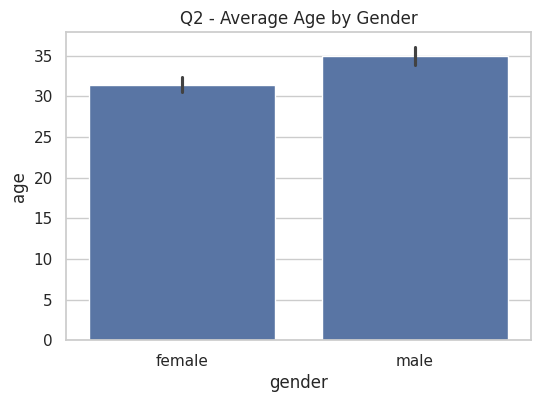

In [21]:
# 2. Average age by gender?

avg_age_gender = df.groupby('gender')['age'].mean()
print("Average Age by Gender:")
print(avg_age_gender)
print("*********************************")

plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='gender', y='age', estimator='mean')
plt.title('Q2 - Average Age by Gender')
plt.show()


3. Number of Users per Gender:
gender
female    106
male      102
Name: count, dtype: int64
**********************


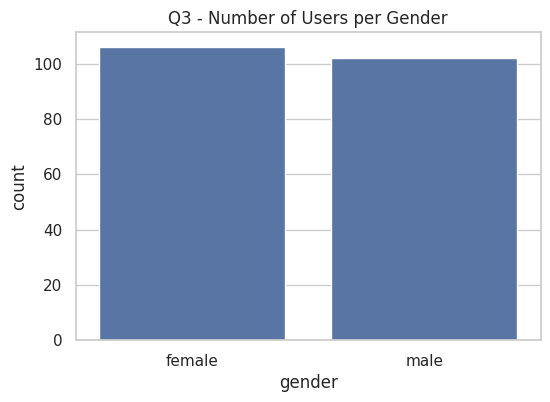

In [22]:
# 3. Number of users per gender?

gender_counts = df['gender'].value_counts()
print("3. Number of Users per Gender:")
print(gender_counts)
print("**********************")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='gender')
plt.title('Q3 - Number of Users per Gender')
plt.show()

4. Top 10 Cities:
city
Phoenix         17
Dallas          15
Jacksonville    14
Los Angeles     14
Seattle         12
Philadelphia    11
Charlotte       11
San Jose        11
Chicago         11
New York        11
Name: count, dtype: int64
****************************


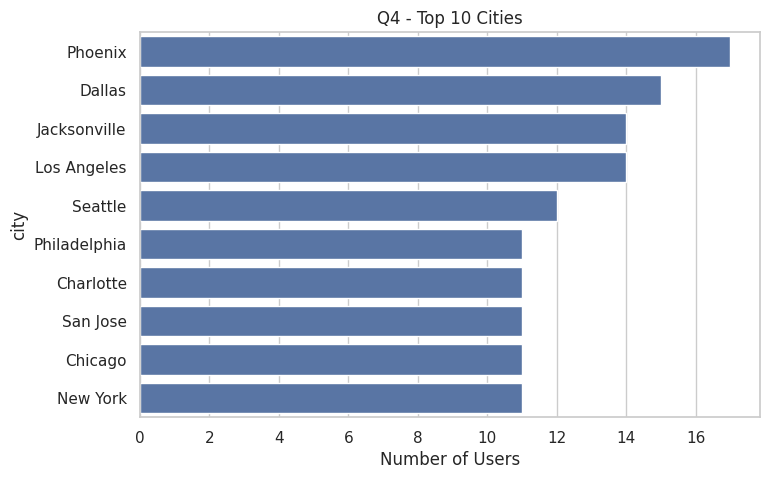

In [23]:
# 4. Top 10 cities with the most users?

top_cities = df['city'].value_counts().head(10)
print("4. Top 10 Cities:")
print(top_cities)
print("****************************")

plt.figure(figsize=(8, 5))
top10 = df['city'].value_counts().head(10)
sns.barplot(x=top10.values, y=top10.index)
plt.title('Q4 - Top 10 Cities')
plt.xlabel('Number of Users')
plt.show()

5. Overall Average Height: 175.72
   Overall Average Weight: 75.04
*****************************


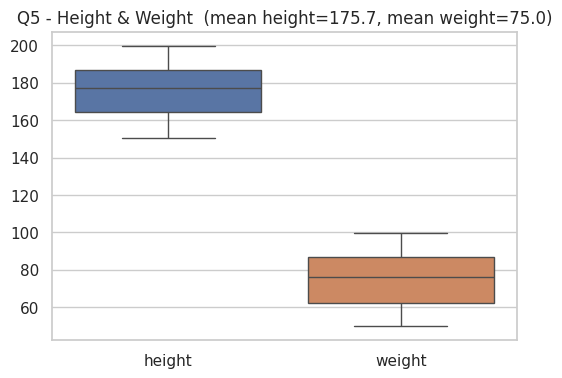

In [24]:
# 5. Average height and weight overall?

avg_height = df['height'].mean()
avg_weight = df['weight'].mean()
print(f"5. Overall Average Height: {avg_height:.2f}")
print(f"   Overall Average Weight: {avg_weight:.2f}")
print("*****************************")

plt.figure(figsize=(6, 4))
sns.boxplot(data=df[['height', 'weight']])
plt.title(f"Q5 - Height & Weight  (mean height={df['height'].mean():.1f}, mean weight={df['weight'].mean():.1f})")
plt.show()

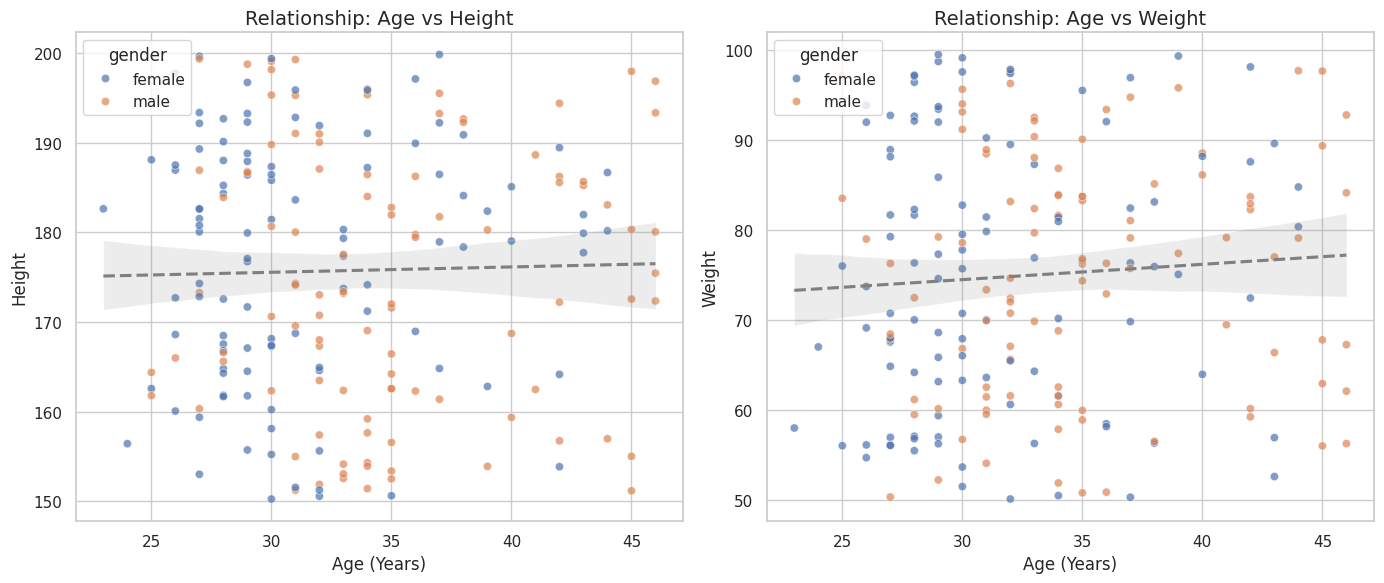

In [ ]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Age vs Height ---

sns.scatterplot(data=df, x='age', y='height', hue='gender', alpha=0.7, ax=axes[0])
sns.regplot(data=df, x='age', y='height', scatter=False, ax=axes[0], color='gray', line_kws={"linestyle": "--"})

axes[0].set_title('Relationship: Age vs Height', fontsize=14)
axes[0].set_xlabel('Age (Years)')
axes[0].set_ylabel('Height')

# --- Plot 2: Age vs Weight ---

sns.scatterplot(data=df, x='age', y='weight', hue='gender', alpha=0.7, ax=axes[1])
sns.regplot(data=df, x='age', y='weight', scatter=False, ax=axes[1], color='gray', line_kws={"linestyle": "--"})

axes[1].set_title('Relationship: Age vs Weight', fontsize=14)
axes[1].set_xlabel('Age (Years)')
axes[1].set_ylabel('Weight')

plt.tight_layout()
plt.show()